In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('../data/creditcard.csv')

In [5]:
scaler=StandardScaler()
df['Amount_scld']=scaler.fit_transform(df[['Amount']])
df['Time_scld']=scaler.fit_transform(df[['Time']])
df.drop(['Amount','Time'],axis=1,inplace=True)

In [6]:
df[['Amount_scld','Time_scld']].describe()

,Amount_scld,Time_scld
count,2.848070e+05,2.848070e+05
mean,-3.672378e-17,-5.109395e-17
std,1.000002e+00,1.000002e+00
min,-3.532294e-01,-1.996583e+00
25%,-3.308401e-01,-8.552120e-01
50%,-2.652715e-01,-2.131453e-01
75%,-4.471707e-02,9.372174e-01
max,1.023622e+02,1.642058e+00


In [7]:
df.sample(1)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scld,Time_scld
267765,-1.854592,-0.943023,0.468447,-0.777536,0.569638,0.192258,0.007292,0.648478,-0.291015,-1.014283,-0.646416,0.378047,0.604004,0.29474,-0.121569,1.249331,-1.291589,1.273049,0.270695,0.629413,0.457684,0.472098,0.01735,-1.335988,0.067376,0.708497,-0.099555,-0.132053,0,0.418401,1.434132


In [16]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('Class',axis=1),df['Class'],test_size=0.33,random_state=7,stratify=df['Class'])
#stratify is used because there is vey high imbalance in class

In [19]:
print('Before SMOTE - Train class distribution:')
print(y_train.value_counts())

smote=SMOTE(random_state=77)
X_train_sm,y_train_sm=smote.fit_resample(X_train,y_train)

print('After SMOTE - Train class distribution:')
print(y_train_sm.value_counts())
print(f"\nNew training size: {X_train_sm.shape}")


Before SMOTE - Train class distribution:
Class
0    190490
1       330
Name: count, dtype: int64
After SMOTE - Train class distribution:
Class
0    190490
1    190490
Name: count, dtype: int64

New training size: (380980, 30)


### Why SMOTE on train only?
- Test set must reflect real-world distribution (0.17% fraud)
- SMOTE generates synthetic fraud samples for training only
- Evaluating on synthetic test data would give falsely optimistic results

In [20]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save as numpy arrays for fast loading during training
np.save('../data/processed/X_train.npy', X_train_sm)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_train.npy', y_train_sm)
np.save('../data/processed/y_test.npy', y_test)

# Save feature names for SHAP later
feature_names = df.drop('Class',axis=1).columns.tolist()
pd.Series(feature_names).to_csv('../data/processed/feature_names.csv', index=False)

print("All processed data saved to data/processed/")
print(f"Feature names saved: {len(feature_names)} features")

All processed data saved to data/processed/
Feature names saved: 30 features


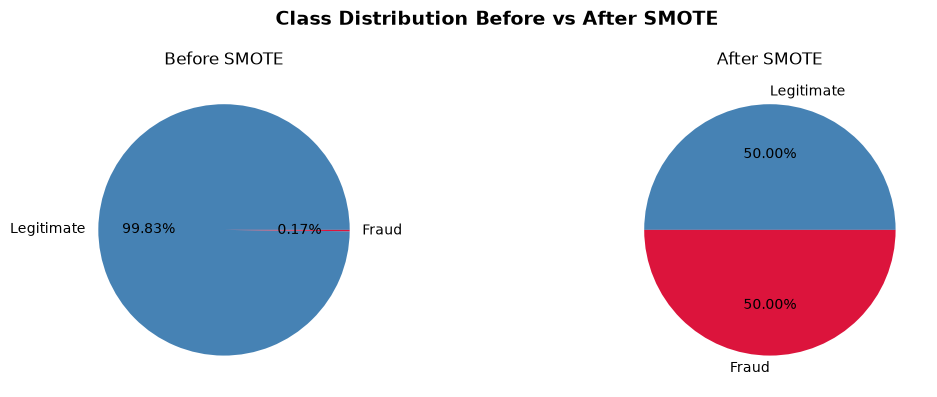

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
axes[0].pie(y_train.value_counts(), 
            labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'crimson'],
            autopct='%1.2f%%')
axes[0].set_title('Before SMOTE')

# After SMOTE
after_counts = pd.Series(y_train_sm).value_counts()
axes[1].pie(after_counts,
            labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'crimson'],
            autopct='%1.2f%%')
axes[1].set_title('After SMOTE')

plt.suptitle('Class Distribution Before vs After SMOTE', 
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()